In [63]:
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF

In [64]:
train_dataset = OxfordIIITPet(
    root="U-Nets/U-Nets/data",
    split="trainval",
    target_types="segmentation",
    download=False
)

test_dataset = OxfordIIITPet(
    root="U-Nets/U-Nets/data",
    split="test",
    target_types="segmentation",
    download=False
)

RuntimeError: Dataset not found. You can use download=True to download it

In [65]:
from torch.utils.data import Subset
import random

target_size = (500, 375)
keep_ratio = 0.20

matching_indices = []

for idx in range(len(train_dataset)):
    image, mask = train_dataset[idx]

    image_size = image.shape[-2:] if hasattr(image, "shape") else image.size

    if image_size == target_size:
        matching_indices.append(idx)

num_keep = int(len(matching_indices) * keep_ratio)

random.seed(42)
selected_indices = random.sample(matching_indices, num_keep)

train_subset = Subset(train_dataset, selected_indices)

print("Original matching images:", len(matching_indices))
print("Selected training images:", len(train_subset))

print(train_subset[0])

Original matching images: 770
Selected training images: 154
(<PIL.Image.Image image mode=RGB size=500x375 at 0x11A832AC0>, <PIL.PngImagePlugin.PngImageFile image mode=L size=500x375 at 0x11A832040>)


In [66]:
print(train_subset[0])

(<PIL.Image.Image image mode=RGB size=500x375 at 0x11A83C2B0>, <PIL.PngImagePlugin.PngImageFile image mode=L size=500x375 at 0x11A83C310>)


In [67]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset


class PetSegmentationDataset(Dataset):
    def __init__(self, dataset, image_size=(512, 384)):
        self.dataset = dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        image = TF.resize(image, self.image_size, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.image_size, interpolation=InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        mask = (mask != 2).float().unsqueeze(0)

        return image, mask


train_seg_dataset = PetSegmentationDataset(train_subset)
train_loader = DataLoader(train_seg_dataset, batch_size=1, shuffle=True)

images, masks = next(iter(train_loader))

print("images:", images.shape)
print("masks:", masks.shape)
print("mask values:", masks.unique())


images: torch.Size([1, 3, 512, 384])
masks: torch.Size([1, 1, 512, 384])
mask values: tensor([0., 1.])


In [ ]:
## loss using IOU or Dice // IOU  = Intersection / Union and dice = 2 * Intersection / (Size A + Size B)
## image -- > conv2D -> relu --relu--> conv2D -- forCcat , maxPool (2x2) 

## 393x500 --> 196x250 --> 98x125

In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [69]:
## conv2D->relu->conv2D-->relu
class DoubleConv(nn.Module):
    def __init__(self, in_channels,out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [70]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down1 = DoubleConv(3, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

    def forward(self, x):
        skip1 = self.down1(x)
        x = self.pool(skip1)

        skip2 = self.down2(x)
        x = self.pool(skip2)

        skip3 = self.down3(x)
        x = self.pool(skip3)

        skip4 = self.down4(x)
        x = self.pool(skip4)

        x = self.bottleneck(x)

        return x, skip1, skip2, skip3, skip4

In [71]:
encoder = Encoder()

x = torch.randn(1, 3, 512, 384)

latent, skip1, skip2, skip3, skip4 = encoder(x)

print("skip1:", skip1.shape)
print("skip2:", skip2.shape)
print("skip3:", skip3.shape)
print("skip4:", skip4.shape)
print("latent:", latent.shape)

skip1: torch.Size([1, 64, 512, 384])
skip2: torch.Size([1, 128, 256, 192])
skip3: torch.Size([1, 256, 128, 96])
skip4: torch.Size([1, 512, 64, 48])
latent: torch.Size([1, 1024, 32, 24])


In [72]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        x = torch.cat([skip, x], dim=1)

        x = self.conv(x)

        return x

In [73]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.up1 = UpBlock(1024, 512, 512)
        self.up2 = UpBlock(512, 256, 256)
        self.up3 = UpBlock(256, 128, 128)
        self.up4 = UpBlock(128, 64, 64)

        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, latent, skip1, skip2, skip3, skip4):
        x = self.up1(latent, skip4)
        x = self.up2(x, skip3)
        x = self.up3(x, skip2)
        x = self.up4(x, skip1)

        x = self.final_conv(x)

        return x

In [74]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent, skip1, skip2, skip3, skip4 = self.encoder(x)

        out = self.decoder(latent, skip1, skip2, skip3, skip4)

        return out

In [75]:
model = UNet()

x = torch.randn(1, 3, 512, 384)

out = model(x)

print(out.shape)

torch.Size([1, 1, 512, 384])


In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


def dice_loss_from_logits(logits, masks, eps=1e-7):
    probs = torch.sigmoid(logits)

    intersection = (probs * masks).sum(dim=(1, 2, 3))
    probs_sum = probs.sum(dim=(1, 2, 3))
    masks_sum = masks.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (probs_sum + masks_sum + eps)

    return 1 - dice.mean()

In [77]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_bce_loss = 0
    total_dice_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        masks = masks.float()

        logits = model(images)

        bce_loss = loss_fn(logits, masks)
        dice_loss = dice_loss_from_logits(logits, masks)
        loss = bce_loss + dice_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce_loss += bce_loss.item()
        total_dice_loss += dice_loss.item()

    avg_loss = total_loss / len(train_loader)
    avg_bce_loss = total_bce_loss / len(train_loader)
    avg_dice_loss = total_dice_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {avg_loss:.4f}, "
        f"BCE: {avg_bce_loss:.4f}, "
        f"Dice: {avg_dice_loss:.4f}"
    )

Epoch 1/10, Loss: 1.2816, BCE: 0.6872, Dice: 0.5945
Epoch 2/10, Loss: 1.2806, BCE: 0.6834, Dice: 0.5972
Epoch 3/10, Loss: 1.2751, BCE: 0.6748, Dice: 0.6003
Epoch 4/10, Loss: 1.2429, BCE: 0.6538, Dice: 0.5891
Epoch 5/10, Loss: 1.2156, BCE: 0.6611, Dice: 0.5546
Epoch 6/10, Loss: 1.1790, BCE: 0.6336, Dice: 0.5454
Epoch 7/10, Loss: 1.0293, BCE: 0.5755, Dice: 0.4538
Epoch 8/10, Loss: 0.9913, BCE: 0.5664, Dice: 0.4249
Epoch 9/10, Loss: 0.9632, BCE: 0.5474, Dice: 0.4158
Epoch 10/10, Loss: 0.9499, BCE: 0.5419, Dice: 0.4080


## Test predictions

This is binary segmentation, so use `sigmoid` on the raw logits. `softmax` is for multi-class masks with multiple output channels.

In [78]:
def dice_score(pred_mask, true_mask, eps=1e-7):
    pred_mask = pred_mask.float()
    true_mask = true_mask.float()

    intersection = (pred_mask * true_mask).sum(dim=(1, 2, 3))
    pred_sum = pred_mask.sum(dim=(1, 2, 3))
    true_sum = true_mask.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (pred_sum + true_sum + eps)
    return dice.mean()


def iou_score(pred_mask, true_mask, eps=1e-7):
    pred_mask = pred_mask.float()
    true_mask = true_mask.float()

    intersection = (pred_mask * true_mask).sum(dim=(1, 2, 3))
    union = pred_mask.sum(dim=(1, 2, 3)) + true_mask.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean()


In [79]:
def dice_score(pred_mask, true_mask, eps=1e-7):
    pred_mask = pred_mask.float()
    true_mask = true_mask.float()

    intersection = (pred_mask * true_mask).sum(dim=(1, 2, 3))
    pred_sum = pred_mask.sum(dim=(1, 2, 3))
    true_sum = true_mask.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (pred_sum + true_sum + eps)

    return dice.mean()

In [80]:
def iou_score(pred_mask, true_mask, eps=1e-7):
    pred_mask = pred_mask.float()
    true_mask = true_mask.float()

    intersection = (pred_mask * true_mask).sum(dim=(1, 2, 3))
    union = pred_mask.sum(dim=(1, 2, 3)) + true_mask.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)

    return iou.mean()

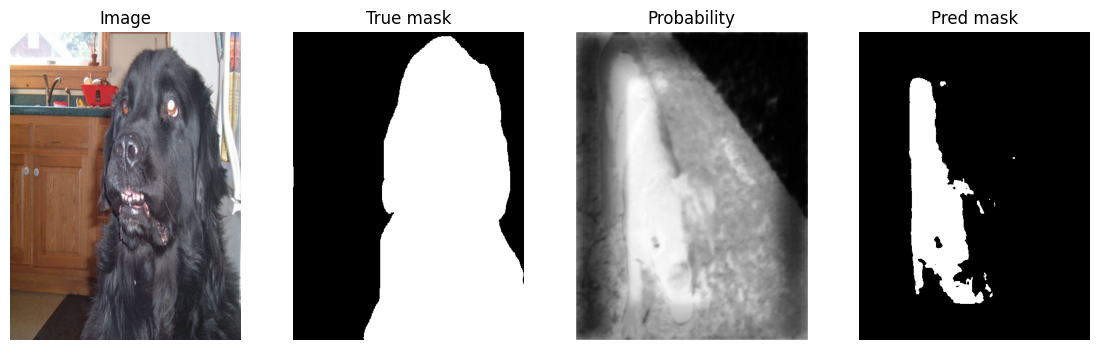

In [81]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("matplotlib is not installed, so plotting is skipped.")
else:
    image_to_show = images[0].detach().cpu().permute(1, 2, 0)
    true_mask_to_show = masks[0, 0].detach().cpu()
    prob_to_show = probs[0, 0].detach().cpu()
    pred_mask_to_show = pred_masks[0, 0].detach().cpu()

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image_to_show)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask_to_show, cmap="gray")
    plt.title("True mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(prob_to_show, cmap="gray")
    plt.title("Probability")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(pred_mask_to_show, cmap="gray")
    plt.title("Pred mask")
    plt.axis("off")

    plt.show()
